# pywhyllm — Sea Ice Causality Example

A realistic causal discovery workflow over Arctic sea ice climate variables.

**What this notebook covers:**
- Building a causal graph over 10 climate variables
- Expert consensus (parallel calls)
- Local graph queries — zero extra LLM calls
- Confounders, latent confounders, negative controls
- Graph validation via critique
- API call count vs the old pairwise approach

In [7]:
%pip install -e ../.. instructor openai python-dotenv --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: /Users/grace/Library/Caches/pypoetry/virtualenvs/pywhyllm-2Ly9bi-b-py3.13/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from dotenv import load_dotenv
load_dotenv()  # reads OPENAI_API_KEY from a .env file

# Or set directly for quick testing (don't commit real keys!):
# import os; os.environ["OPENAI_API_KEY"] = "sk-..."

In [9]:
import instructor
from openai import AsyncOpenAI

from pywhyllm.suggesters import ModelSuggester, CausalGraph

client = instructor.from_openai(AsyncOpenAI())

suggester = ModelSuggester(
    client=client,
    model="gpt-4o-mini",
    context="Arctic climate systems and sea ice dynamics",
)

## Variables

Ten atmospheric and oceanic variables relevant to Arctic sea ice extent.

In [10]:
variables = [
    "geopotential_heights",
    "relative_humidity",
    "sea_level_pressure",
    "zonal_wind_at_10_meters",
    "meridional_wind_at_10_meters",
    "total_precipitation",
    "surface_temperature",
    "sea_ice_extent",
    "ocean_heat_content",
    "longwave_radiation",
]

# Treatment and outcome of interest
treatment = "surface_temperature"
outcome   = "sea_ice_extent"

## Step 1 — Suggest domain experts

One LLM call returns expert roles relevant to causal reasoning over these variables.

In [11]:
experts = await suggester.suggest_domain_experts(variables, n_experts=3)
print("Experts:", experts)

Experts: ['Atmospheric scientist / meteorologist specializing in synoptic-scale dynamics and boundary-layer processes', 'Climate scientist / climate dynamicist with expertise in air-sea interactions and coupled climate variability', 'Physical oceanographer / cryosphere scientist with expertise in ocean heat content, sea ice extent, and coupled ocean-ice-atmosphere feedbacks']


## Step 2 — Build the causal graph

**Without experts**: 1 LLM call, generic persona.  
**With experts**: 1 call *per expert*, fired in parallel — edges merged by vote count.

For 10 variables the old pairwise approach would have made **10C2 × 3 = 135 sequential calls**.  
The new approach makes **3 parallel calls** — the variable count is irrelevant.

In [12]:
# 3 parallel calls — one per expert
graph = await suggester.suggest_graph(variables, expertise_list=experts)
print(graph)

CausalGraph (26 edges):
  (A → B means A causes B)
  surface_temperature → longwave_radiation  (votes: 3, confidence: 0.93)
  surface_temperature → sea_ice_extent  (votes: 3, confidence: 0.92)
  sea_level_pressure → zonal_wind_at_10_meters  (votes: 3, confidence: 0.91)
  sea_level_pressure → meridional_wind_at_10_meters  (votes: 3, confidence: 0.91)
  ocean_heat_content → surface_temperature  (votes: 3, confidence: 0.86)
  geopotential_heights → sea_level_pressure  (votes: 3, confidence: 0.83)
  longwave_radiation → surface_temperature  (votes: 3, confidence: 0.83)
  surface_temperature → relative_humidity  (votes: 3, confidence: 0.82)
  zonal_wind_at_10_meters → sea_ice_extent  (votes: 3, confidence: 0.77)
  meridional_wind_at_10_meters → sea_ice_extent  (votes: 3, confidence: 0.77)
  sea_ice_extent → surface_temperature  (votes: 2, confidence: 0.84)
  ocean_heat_content → sea_ice_extent  (votes: 2, confidence: 0.84)
  geopotential_heights → zonal_wind_at_10_meters  (votes: 2, confide

## Step 3 — Filter by consensus

`top_edges(min_votes=2)` keeps only edges at least 2 experts agreed on. Zero LLM calls.

In [13]:
consensus_edges = graph.top_edges(min_votes=2)
print(f"{len(consensus_edges)} edges with ≥2 expert votes:\n")
for (cause, effect), data in consensus_edges:
    print(f"  {cause} → {effect}  (votes: {data.votes}, avg confidence: {data.avg_confidence:.2f})")

19 edges with ≥2 expert votes:

  surface_temperature → longwave_radiation  (votes: 3, avg confidence: 0.93)
  surface_temperature → sea_ice_extent  (votes: 3, avg confidence: 0.92)
  sea_level_pressure → zonal_wind_at_10_meters  (votes: 3, avg confidence: 0.91)
  sea_level_pressure → meridional_wind_at_10_meters  (votes: 3, avg confidence: 0.91)
  ocean_heat_content → surface_temperature  (votes: 3, avg confidence: 0.86)
  geopotential_heights → sea_level_pressure  (votes: 3, avg confidence: 0.83)
  longwave_radiation → surface_temperature  (votes: 3, avg confidence: 0.83)
  surface_temperature → relative_humidity  (votes: 3, avg confidence: 0.82)
  zonal_wind_at_10_meters → sea_ice_extent  (votes: 3, avg confidence: 0.77)
  meridional_wind_at_10_meters → sea_ice_extent  (votes: 3, avg confidence: 0.77)
  sea_ice_extent → surface_temperature  (votes: 2, avg confidence: 0.84)
  ocean_heat_content → sea_ice_extent  (votes: 2, avg confidence: 0.84)
  geopotential_heights → zonal_wind_at_

## Step 4 — Local graph queries

All structural queries are local — **zero LLM calls** after the graph is built.

In [14]:
print("Parents of sea_ice_extent:",   graph.parents_of("sea_ice_extent"))
print("Children of surface_temperature:", graph.children_of("surface_temperature"))
print("Ancestors of sea_ice_extent:",  graph.ancestors_of("sea_ice_extent"))
print()
print("Mediators (surface_temperature → sea_ice_extent):",
      graph.mediators_of(treatment, outcome))
print("Instrumental variables (surface_temperature → sea_ice_extent):",
      graph.instrumental_variables_for(treatment, outcome))

Parents of sea_ice_extent: ['zonal_wind_at_10_meters', 'meridional_wind_at_10_meters', 'surface_temperature', 'ocean_heat_content']
Children of surface_temperature: ['longwave_radiation', 'sea_ice_extent', 'relative_humidity']
Ancestors of sea_ice_extent: ['sea_level_pressure', 'relative_humidity', 'meridional_wind_at_10_meters', 'zonal_wind_at_10_meters', 'sea_ice_extent', 'ocean_heat_content', 'total_precipitation', 'longwave_radiation', 'surface_temperature', 'geopotential_heights']

Mediators (surface_temperature → sea_ice_extent): ['relative_humidity', 'ocean_heat_content', 'total_precipitation', 'longwave_radiation', 'surface_temperature', 'sea_ice_extent']
Instrumental variables (surface_temperature → sea_ice_extent): []


## Step 5 — Confounders

Find variables that directly cause **both** treatment and outcome.

`latent=True` asks the LLM for unmeasured confounders *outside* the variable list.

In [15]:
confounders = await suggester.suggest_confounders(
    treatment=treatment,
    outcome=outcome,
    variables=variables,
    expertise_list=experts,   # 3 parallel calls, results deduplicated
)
print("Observed confounders:", confounders)

Observed confounders: ['ocean_heat_content', 'longwave_radiation', 'sea_level_pressure', 'zonal_wind_at_10_meters', 'meridional_wind_at_10_meters', 'geopotential_heights']


In [16]:
latent = await suggester.suggest_confounders(
    treatment=treatment,
    outcome=outcome,
    variables=variables,
    latent=True,
)
print("Latent confounders:", latent)

Latent confounders: ['shortwave_radiation', 'cloud_cover', 'surface_albedo', 'ocean_salinity', 'ocean_currents', 'mixed_layer_depth', 'snow_cover', 'arctic_oscillation', 'north_atlantic_oscillation', 'air_temperature_at_2_meters']


## Step 6 — Negative controls

Variables that *should* be unaffected by `surface_temperature`. If your model shows a treatment effect on these, your causal assumptions are wrong.

In [17]:
negative_controls = await suggester.suggest_negative_controls(
    treatment=treatment,
    outcome=outcome,
    variables=variables,
)
print("Negative controls:", negative_controls)

Negative controls: ['geopotential_heights', 'sea_level_pressure', 'zonal_wind_at_10_meters', 'meridional_wind_at_10_meters']


## Step 7 — Critique the graph

Show the LLM the proposed edges and ask: *which are genuinely causal, and what's missing?*  
Returns a new graph — compare against the original to find confirmed vs disputed edges.

In [18]:
critique = await suggester.critique_graph(
    graph=graph,
    variables=variables,
    expertise_list=experts,   # 3 parallel calls
)

original_edges = set(graph.edges)
for (cause, effect) in sorted(original_edges):
    status = "✓ CONFIRMED" if critique.edge_data(cause, effect) else "✗ DISPUTED"
    print(f"  {status}: {cause} → {effect}")

new_edges = [(c, e) for (c, e) in critique.edges if (c, e) not in original_edges]
if new_edges:
    print("\nNew edges suggested by critique:")
    for (cause, effect) in new_edges:
        print(f"  + {cause} → {effect}")

  ✓ CONFIRMED: geopotential_heights → meridional_wind_at_10_meters
  ✓ CONFIRMED: geopotential_heights → sea_level_pressure
  ✓ CONFIRMED: geopotential_heights → zonal_wind_at_10_meters
  ✗ DISPUTED: longwave_radiation → surface_temperature
  ✓ CONFIRMED: meridional_wind_at_10_meters → ocean_heat_content
  ✓ CONFIRMED: meridional_wind_at_10_meters → sea_ice_extent
  ✓ CONFIRMED: meridional_wind_at_10_meters → total_precipitation
  ✓ CONFIRMED: ocean_heat_content → sea_ice_extent
  ✓ CONFIRMED: ocean_heat_content → surface_temperature
  ✓ CONFIRMED: relative_humidity → longwave_radiation
  ✓ CONFIRMED: relative_humidity → total_precipitation
  ✓ CONFIRMED: sea_ice_extent → longwave_radiation
  ✓ CONFIRMED: sea_ice_extent → ocean_heat_content
  ✓ CONFIRMED: sea_ice_extent → surface_temperature
  ✓ CONFIRMED: sea_level_pressure → geopotential_heights
  ✓ CONFIRMED: sea_level_pressure → meridional_wind_at_10_meters
  ✓ CONFIRMED: sea_level_pressure → total_precipitation
  ✓ CONFIRMED: sea_

## Step 8 — Inspect edge reasoning

Every edge stores per-expert reasoning. Useful for auditing *why* the model believes a relationship exists.

In [19]:
data = graph.edge_data("surface_temperature", "sea_ice_extent")
if data:
    print(f"Votes: {data.votes}")
    print(f"Avg confidence: {data.avg_confidence:.2f}")
    print("Expert reasoning:")
    for i, r in enumerate(data.reasonings, 1):
        print(f"  [{i}] {r}")
else:
    print("Edge not in graph.")

Votes: 3
Avg confidence: 0.92
Expert reasoning:
  [1] Surface temperature directly controls sea ice growth and melt through the surface energy balance. Warmer temperatures promote melt and reduce extent, while colder temperatures promote freezing and expansion of ice cover.
  [2] Higher surface temperatures reduce sea ice growth and promote melt, directly decreasing sea ice extent; colder temperatures increase it.
  [3] Higher surface temperature promotes sea-ice melt and reduces extent; lower temperature favors growth. This is a direct thermodynamic effect on sea ice at the surface.


## Step 9 — Visualise the graph

`plot()` uses Graphviz's `dot` engine, which topologically sorts nodes into ranks so causal direction reads left-to-right naturally.

- **Edge thickness + colour** → average confidence (dark blue = high, grey = lower)
- **Edge label** → confidence %; vote count shown when using multiple experts
- **Node labels** → underscores replaced with spaces for readability

Requires: `pip install graphviz` + `brew install graphviz` (macOS) / `apt-get install graphviz` (Linux)

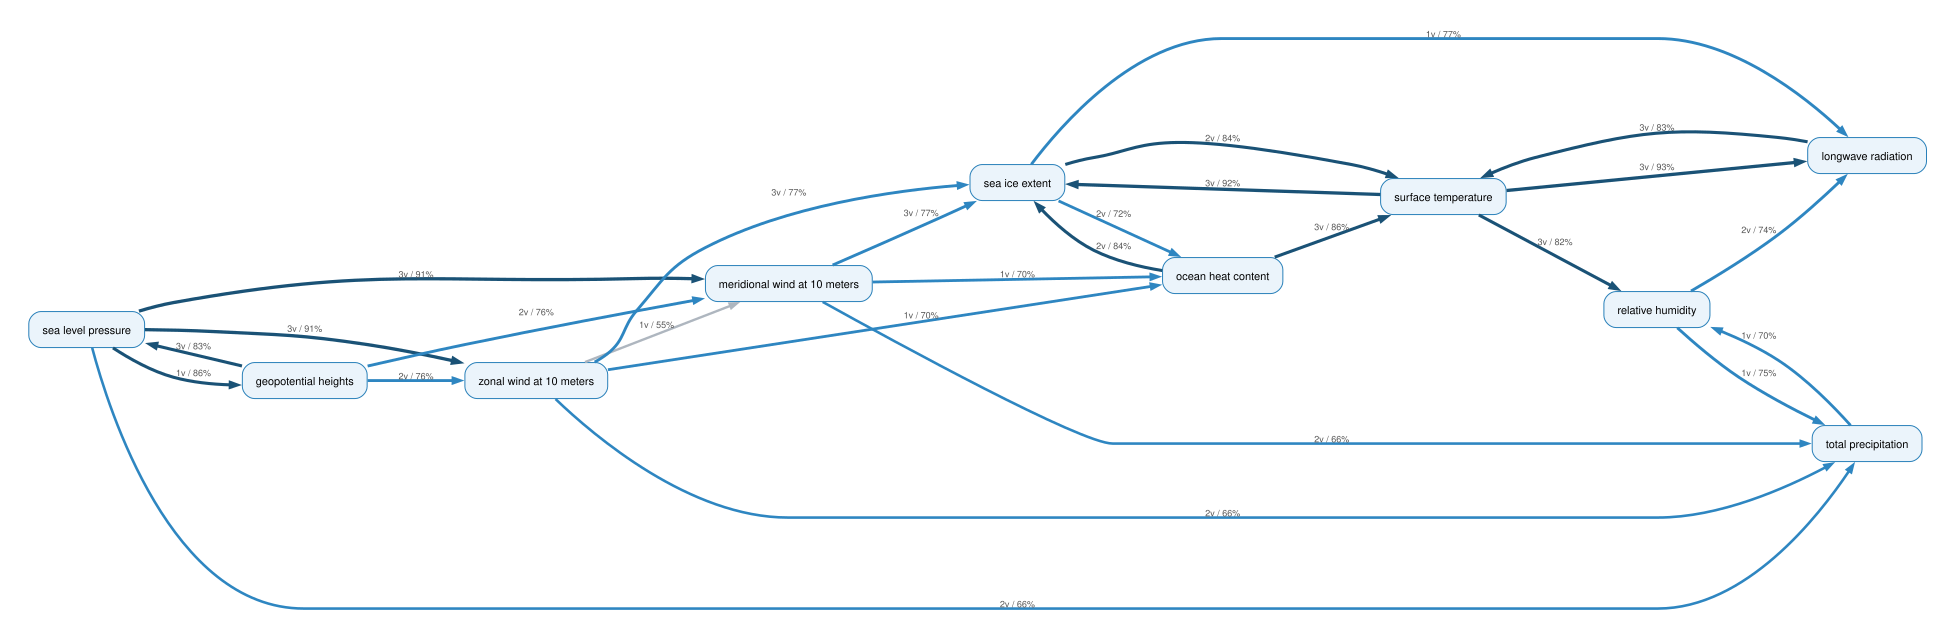

In [20]:
# Render inline in Jupyter
graph.plot()

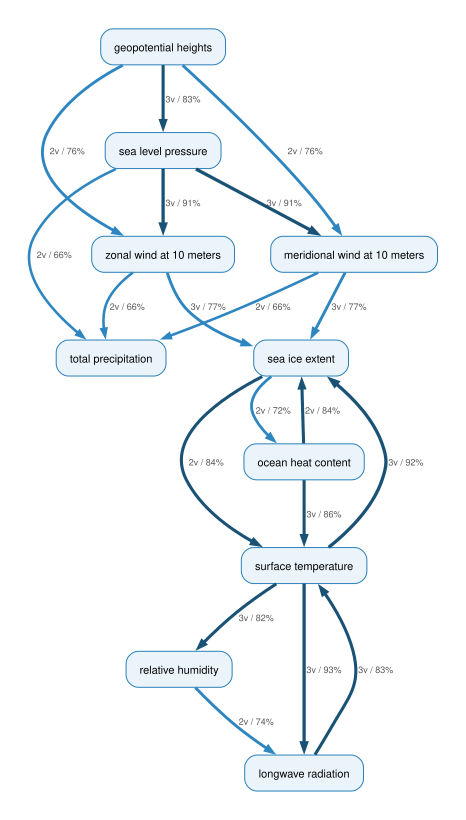

In [21]:
# Consensus edges only (≥2 expert votes), top-to-bottom layout
graph.plot(min_votes=2, rankdir="TB")

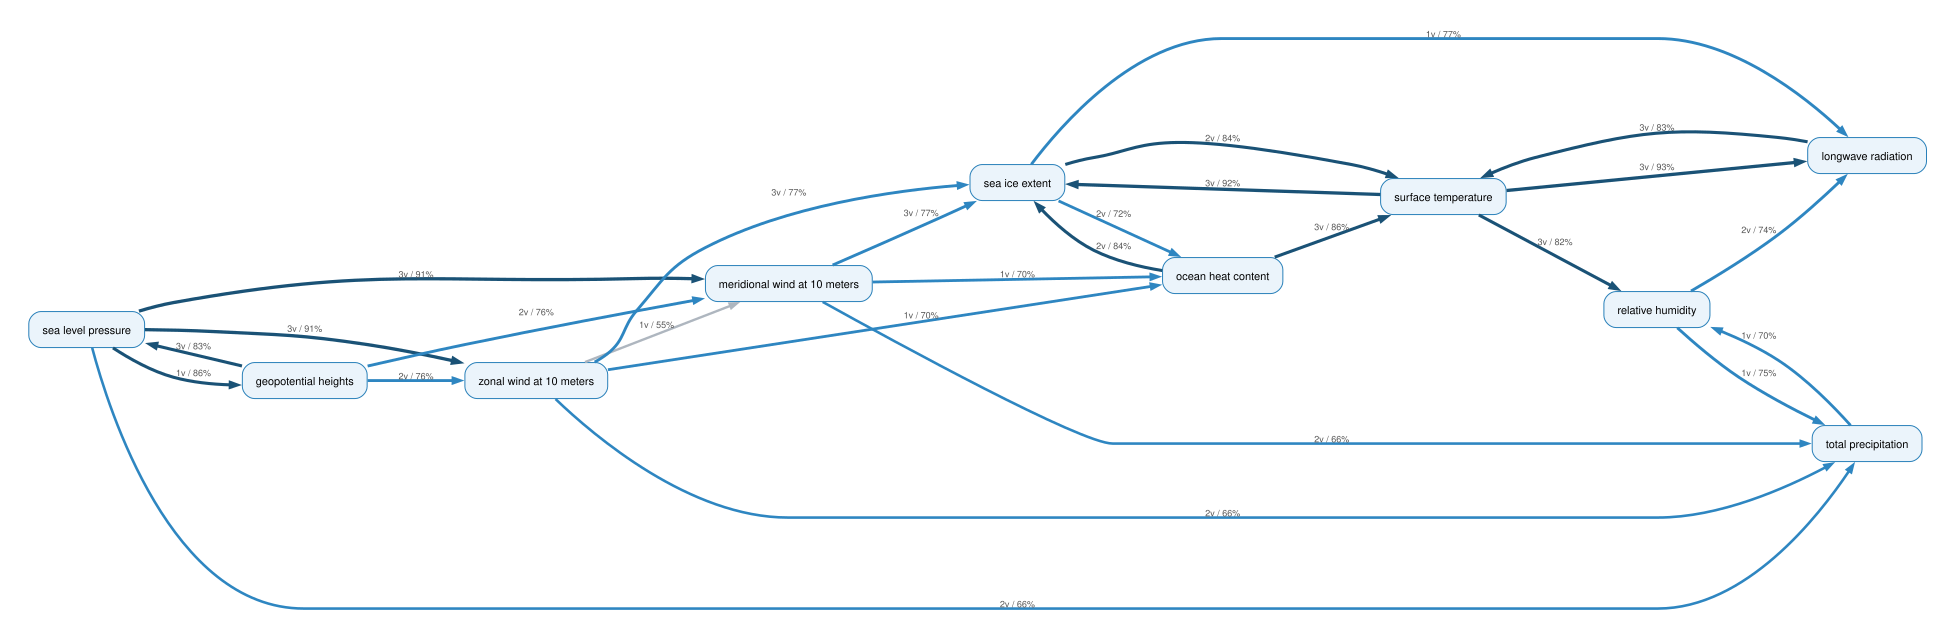

In [22]:
# Save to file
graph.plot(filename="sea_ice_causal_graph", format="png")